In [5]:
import rebound
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import signal
import heyoka as hy
from celmech import Poincare, PoincareHamiltonian
from celmech.disturbing_function import laplace_b, df_coefficient_Ctilde, evaluate_df_coefficient_dict
import symengine as se
import time
import sympy as sp
from sympy import init_printing

In [6]:
#constants and helper functions
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

#from celmech docs
def get_pomega(kap,eta):
    return np.arctan2(-eta,kap)

def get_ecc(kap,eta,L):
    P = (kap**2 + eta**2)/2
    return np.sqrt(1 - (1 - P/L)**2)

In [11]:
def hk_integrate(pham, sim_time, num_data_points):
    H_se = se.sympify(pham.H)
    clean_params_se = {se.sympify(k): v for k, v in dict(pham.H_params).items()
                      if not (hasattr(v, '__float__') and np.isnan(float(v)))}
    H_num = H_se.subs(clean_params_se)
    nan_symbols = {s: 0 for s in H_num.free_symbols
                   if str(s) not in {'Lambda1', 'Lambda2', 'eta1', 'eta2',
                                     'kappa1', 'kappa2', 'lambda1', 'lambda2',
                                     'rho1', 'rho2', 'sigma1', 'sigma2'}}
    H_num = H_num.subs(nan_symbols)

    rho1, rho2, sigma1, sigma2 = se.symbols('rho1 rho2 sigma1 sigma2')
    sym_map = {s: 0 for s in H_num.free_symbols if str(s) in ('rho1', 'rho2', 'sigma1', 'sigma2')}
    H_planar = H_num.subs(sym_map)
    H_planar = se.sympify(H_planar)
    print(sorted(str(s) for s in H_planar.free_symbols))

    lam1, lam2 = se.symbols('lambda1 lambda2')
    Lam1, Lam2 = se.symbols('Lambda1 Lambda2')
    eta1, eta2 = se.symbols('eta1 eta2')
    kap1, kap2 = se.symbols('kappa1 kappa2')

    print('*** Differentiating ***')

    sym_dict = {str(s): s for s in H_planar.free_symbols}
    lam1 = sym_dict['lambda1']
    lam2 = sym_dict['lambda2']
    Lam1 = sym_dict['Lambda1']
    Lam2 = sym_dict['Lambda2']
    eta1 = sym_dict['eta1']
    eta2 = sym_dict['eta2']
    kap1 = sym_dict['kappa1']
    kap2 = sym_dict['kappa2']

    vars_list = [lam1, Lam1, lam2, Lam2, eta1, kap1, eta2, kap2]

    dLam1_dt = -se.diff(H_planar, lam1)
    dLam2_dt = -se.diff(H_planar, lam2)
    dlam1_dt =  se.diff(H_planar, Lam1)
    dlam2_dt =  se.diff(H_planar, Lam2)
    deta1_dt =  se.diff(H_planar, kap1)
    dkap1_dt = -se.diff(H_planar, eta1)
    deta2_dt =  se.diff(H_planar, kap2)
    dkap2_dt = -se.diff(H_planar, eta2)

    derivs = [dlam1_dt, dLam1_dt, dlam2_dt, dLam2_dt, deta1_dt, dkap1_dt, deta2_dt, dkap2_dt]

    # --- MEGNO: build Jacobian J[i,j] = d(derivs[i])/d(vars_list[j]) ---
    print('*** Computing Jacobian for MEGNO variational equations ***')
    n_vars = len(vars_list)
    jacobian = [[se.diff(derivs[i], vars_list[j]) for j in range(n_vars)] for i in range(n_vars)]

    func = se.Lambdify(vars_list, H_planar)

    jup = pham.state.particles[1]
    sat = pham.state.particles[2]

    initial_conditions = [jup.l, jup.Lambda, sat.l, sat.Lambda,
                          jup.eta, jup.kappa, sat.eta, sat.kappa]

    # --- heyoka variables: 8 state + 8 variational (w) + 2 MEGNO (Y_acc, w_dot_w_acc) ---
    lam1_hy, Lam1_hy, lam2_hy, Lam2_hy, eta1_hy, kap1_hy, eta2_hy, kap2_hy = hy.make_vars(
        'lam1_hy', 'Lam1_hy', 'lam2_hy', 'Lam2_hy', 'eta1_hy', 'kap1_hy', 'eta2_hy', 'kap2_hy')

    # Variational shadow variables w[0..7]
    w_hy = list(hy.make_vars(*[f'w{i}_hy' for i in range(n_vars)]))

    # MEGNO accumulator Y and running norm accumulator (for <Y>)
    Y_hy, megno_acc_hy = hy.make_vars('Y_hy', 'megno_acc_hy')

    sym_to_hy = {
        sp.Symbol('lambda1'): lam1_hy,
        sp.Symbol('Lambda1'): Lam1_hy,
        sp.Symbol('lambda2'): lam2_hy,
        sp.Symbol('Lambda2'): Lam2_hy,
        sp.Symbol('eta1'):    eta1_hy,
        sp.Symbol('kappa1'):  kap1_hy,
        sp.Symbol('eta2'):    eta2_hy,
        sp.Symbol('kappa2'):  kap2_hy,
    }

    def to_hy(expr):
        return hy.from_sympy(sp.sympify(expr), sym_to_hy)

    # Main equations of motion
    eqs_hy = [to_hy(eq) for eq in derivs]

    # Variational equations:  dw/dt = J(q) * w
    dw_hy = []
    for i in range(n_vars):
        row_sum = sum(to_hy(jacobian[i][j]) * w_hy[j] for j in range(n_vars))
        dw_hy.append(row_sum)

    # MEGNO integrand: dY/dt = t * (w · dw/dt) / (w · w)
    # Use heyoka's time variable hy.time
    w_dot_dw = sum(w_hy[i] * dw_hy[i] for i in range(n_vars))
    w_dot_w  = sum(w_hy[i] * w_hy[i]  for i in range(n_vars))
    dY_dt    = hy.time * w_dot_dw / w_dot_w

    # <Y>(t) = Y(t) / t  is computed in post-processing; 
    # we also track the integral of Y for a smoother estimate via:
    # d(megno_acc)/dt = Y/t  ->  <Y> = megno_acc / t  (optional running mean)
    # Simple approach: just store Y, divide by t at output time.

    # Build full ODE system
    state_vars = [lam1_hy, Lam1_hy, lam2_hy, Lam2_hy, eta1_hy, kap1_hy, eta2_hy, kap2_hy]
    full_sys = (
        [(state_vars[i], eqs_hy[i]) for i in range(n_vars)] +
        [(w_hy[i], dw_hy[i])        for i in range(n_vars)] +
        [(Y_hy, dY_dt)]
    )

    # Initial conditions: state + w (random unit vector) + Y=0
    rng = np.random.default_rng(42)
    w0 = rng.standard_normal(n_vars)
    w0 /= np.linalg.norm(w0)

    ic_full = list(initial_conditions) + list(w0) + [0.0]   # Y starts at 0

    ta = hy.taylor_adaptive(
        sys=full_sys,
        state=ic_full,
        high_accuracy=True,
        time=0.0,
        tol=1e-16
    )

    e_i = float(func(*ta.state[:n_vars]))
    print(f'Initial energy: {e_i}')

    times = np.linspace(0, sim_time, int(num_data_points)) * 2 * np.pi
    e_sat     = np.zeros(len(times))
    pomega_sat = np.zeros(len(times))
    e_j       = np.zeros(len(times))
    pomega_j  = np.zeros(len(times))
    a_sat     = np.zeros(len(times))
    megno     = np.zeros(len(times))   # <Y>(t) = Y(t) / t

    start = time.perf_counter()
    print('*** Starting Simulation ***')

    for i in tqdm(range(len(times))):
        ta.propagate_until(times[i], max_delta_t=float(10))
        s = ta.state

        # Orbital quantities (indices 0-7 are the canonical state)
        L,  eta,  kap  = s[3], s[6], s[7]
        Lj, etaj, kapj = s[1], s[4], s[5]

        e_sat[i]      = get_ecc(kap, eta, L)
        pomega_sat[i] = get_pomega(kap, eta)
        e_j[i]        = get_ecc(kapj, etaj, Lj)
        pomega_j      = get_pomega(kapj, etaj)

        sat_particle  = pham.state.particles[2]
        a_sat[i]      = (L / sat_particle.m) ** 2

        # MEGNO: Y is at index 2*n_vars = 16; <Y> = Y / t
        Y_val = s[2 * n_vars]          # index 16
        t_val = times[i]
        megno[i] = Y_val / t_val if t_val > 0 else 0.0

    end = time.perf_counter()

    e_f = float(func(*ta.state[:n_vars]))
    print(f'Final energy: {e_f}')
    e_per = (np.abs(e_i - e_f) / np.abs(e_i)) * 100
    print(f'Energy percent change: {e_per:.6e} %')
    print(f'Final MEGNO <Y> = {megno[-1]:.4f}  (≈2 → regular, >> 2 → chaotic)')
    print('*** Simulation Complete ***')
    print(f'Time elapsed = {end - start:.2f} seconds')

    return times, pomega_sat, e_sat, a_sat, megno

Initial Energy: -8.880166636027647e-05
['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating ***
*** Computing Jacobian for MEGNO variational equations ***
Initial energy: -8.880166636027652e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 21765.01it/s]


Final energy: -8.880166636029732e-05
Energy percent change: 2.342651e-11 %
Final MEGNO <Y> = 172993722945609539375143162904313856.0000  (≈2 → regular, >> 2 → chaotic)
*** Simulation Complete ***
Time elapsed = 4.60 seconds
Megno Value: 1.7299372294560954e+35


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heyoka (with secular terms)')

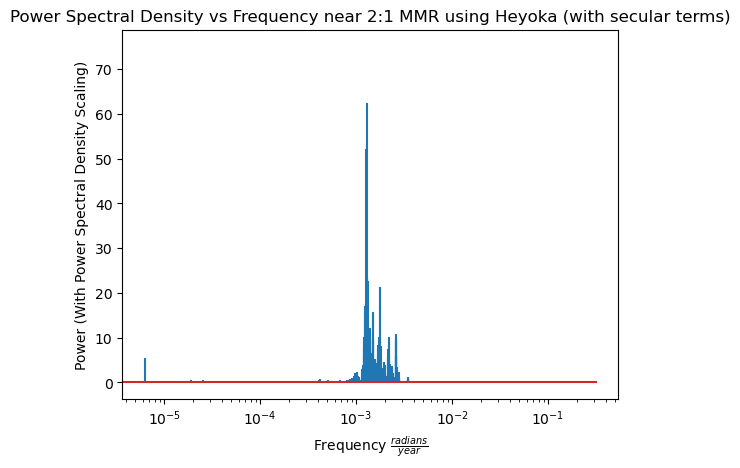

In [14]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_cosine_term([0,0,1,-1,0,0], indexIn = 1, indexOut=2)
pham.add_cosine_term([2,-1,0,-1,0,0],indexIn=1,indexOut=2)

e_i = pham.calculate_energy()
print('Initial Energy: '+ str(e_i))

times, pomega_sat, e_sat, a_sat, megno_val = hk_integrate(pham, 1e6, 1e5)

print('Megno Value: ' + str(megno_val[-1]))

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heyoka (with secular terms)')

Initial Energy: -0.00010493997990334776
['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating ***
*** Computing Jacobian for MEGNO variational equations ***
Initial energy: -0.00010493997990334776
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 22464.48it/s]


Final energy: -0.00010493997990331777
Energy percent change: 2.857990e-11 %
Final MEGNO <Y> = 662662718515.0531  (≈2 → regular, >> 2 → chaotic)
*** Simulation Complete ***
Time elapsed = 4.45 seconds
Megno Value: 662662718515.0531


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heyoka (with secular terms)')

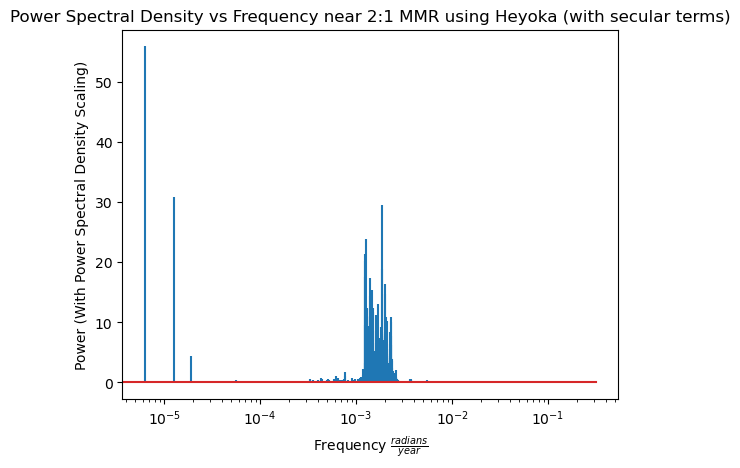

In [15]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_cosine_term([0,0,1,-1,0,0], indexIn = 1, indexOut=2)
pham.add_cosine_term([2,-1,0,-1,0,0],indexIn=1,indexOut=2)

e_i = pham.calculate_energy()
print('Initial Energy: '+ str(e_i))

times, pomega_sat, e_sat, a_sat, megno_val = hk_integrate(pham, 1e6, 1e5)

print('Megno Value: ' + str(megno_val[-1]))

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heyoka (with secular terms)')